
# Pittsburgh Neighborhood Safety Score  
## Faaz's Individual Project Notebook

**My Project idea:** Build a weighted algorithm that uses multiple public Pittsburgh safety related datasets to assign each neighborhood a **safety score from 0 to 1**, where:

- **0 = least safe**
- **1 = most safe**

The core idea for my notebook is:

1. Load several Pittsburgh neighborhood datasets from a local `data/` folder.
2. Clean and standardize neighborhood names.
3. Convert each dataset into a neighborhood level signal.
4. Normalize all signals to the same scale.
5. Combine them with manual weights based on how serious each type of issue is.
6. Produce a final safety ranking for Pittsburgh neighborhoods.

I use the following datasets:

- Monthly Criminal Activity
- Arrests
- Firearm Seizures
- Fire Incidents
- Non Traffic Citations
- City Facilities

The logic behind the model is that violent or high risk public safety events should matter more than lower severity events. At the same time, neighborhoods with more city facilities may have more resources, services, or public infrastructure, so facilities are treated as a small positive factor.



## Methodology

I use a weighted composite score.

### Risk style datasets
These datasets increase danger and should generally lower a neighborhood's safety score:

- Criminal activity
- Arrests
- Firearm seizures
- Fire incidents
- Non traffic citations

### Positive style dataset
This dataset is treated as a small stabilizing or beneficial factor and should generally raise the safety score:

- City facilities

### Why normalize?
Each dataset has a different scale. For example:

- a neighborhood might have 600 crime records
- another metric might only range from 0 to 30

If I added those raw values directly, the largest scale dataset would dominate the model. To fix that, each metric is normalized to a 0 to 1 range before weighting.

### How the Safety Score is Computed

This model combines multiple datasets (crime, incidents, etc.) into a single safety score using normalization, weighting, and smoothing.

#### 1. Normalize Each Metric

Each dataset is on a different scale, so we first convert all values to a 0–1 range.

Formula:
normalized_value = (value - min) / (max - min)

Where:
- value = original metric value for a neighborhood
- min = smallest value of that metric across all neighborhoods
- max = largest value of that metric across all neighborhoods

This ensures no single dataset dominates the model just because of its scale.

#### 2. Compute Weighted Risk Score

We combine all normalized metrics into one risk score using weights.

Formula:
risk_score = sum(weight_j * normalized_metric_j)

Where:
- weight_j = importance of metric j
- normalized_metric_j = normalized value for metric j

This allows more serious factors (like violent crime) to have a bigger impact than less important ones.

#### 3. Apply Smoothing (Credibility Adjustment)

Neighborhoods with very little data can look artificially safe. To fix this, we adjust scores toward the city average.

Formula:
adjusted_risk = (n * risk_score + k * average_risk) / (n + k)

Where:
- n = number of observations (signal) for the neighborhood
- k = smoothing constant (e.g. 500–1000)
- average_risk = average risk across all neighborhoods

This prevents small-sample bias.

#### 4. Normalize Risk Scores Again

We scale the adjusted risk scores back to a 0–1 range:

normalized_risk = (adjusted_risk - min_risk) / (max_risk - min_risk)

#### 5. Compute Final Safety Score

Finally, we convert risk into safety:

safety_score = 1 - normalized_risk

So:
- higher risk → lower safety score
- lower risk → higher safety score

This produces a more balanced and realistic comparison of neighborhoods.

So:

- **higher risk** → lower safety score
- **lower risk** → higher safety score


In [1]:

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12, 6)
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)



## Step 1: Locate the data files

This notebook is written to work with a folder named `data/` in the same directory as the notebook.

Expected structure:

```text
project-folder/
├── fam146.ipynb
└── faaz_data/
    ├── 2024-2026 Monthly Criminal Activity Dataset.xlsx
    ├── Arrests.csv
    ├── Firearm Seizures Data.csv
    ├── Fire Incidents.csv
    ├── Non-Traffic Citations.csv
    └── City Facilities.csv
```

To make the notebook easier to run in multiple environments, I made it so it also checks a few fallback paths.


In [2]:

def resolve_data_dir():
    candidates = [
        Path("faaz_data"),
        Path("./faaz_data"),
        Path("/mnt/faaz_data"),
        Path("."),
    ]
    for candidate in candidates:
        if candidate.exists():
            required = [
                candidate / "2024-2026 Monthly Criminal Activity Dataset.xlsx",
                candidate / "Arrests.csv",
                candidate / "Firearm Seizures Data.csv",
                candidate / "Fire Incidents.csv",
                candidate / "Non-Traffic Citations.csv",
                candidate / "City Facilities.csv",
            ]
            if all(path.exists() for path in required):
                return candidate
    raise FileNotFoundError(
        "Could not find the required files. Put them in a folder named 'data' next to this notebook."
    )

DATA_DIR = resolve_data_dir()
DATA_DIR


PosixPath('faaz_data')


## Step 2: Load the datasets


In [3]:

crime = pd.read_excel(DATA_DIR / "2024-2026 Monthly Criminal Activity Dataset.xlsx")
arrests = pd.read_csv(DATA_DIR / "Arrests.csv")
firearm = pd.read_csv(DATA_DIR / "Firearm Seizures Data.csv")
fire = pd.read_csv(DATA_DIR / "Fire Incidents.csv")
citations = pd.read_csv(DATA_DIR / "Non-Traffic Citations.csv")
facilities = pd.read_csv(DATA_DIR / "City Facilities.csv")

datasets = {
    "crime": crime,
    "arrests": arrests,
    "firearm": firearm,
    "fire": fire,
    "citations": citations,
    "facilities": facilities,
}

for name, df in datasets.items():
    print(f"{name:10s} -> rows={len(df):,}, columns={len(df.columns)}")


crime      -> rows=89,038, columns=19
arrests    -> rows=66,485, columns=17
firearm    -> rows=4,570, columns=20
fire       -> rows=10,730, columns=19
citations  -> rows=16,295, columns=16
facilities -> rows=412, columns=22



## Step 3: Inspect the neighborhood columns

Different datasets name neighborhood fields differently, so I standardize them before analysis.


In [4]:

for name, df in datasets.items():
    neighborhood_like = [col for col in df.columns if "neighborhood" in col.lower()]
    print(f"{name:10s} -> {neighborhood_like}")


crime      -> ['Neighborhood']
arrests    -> ['INCIDENTNEIGHBORHOOD']
firearm    -> ['neighborhood']
fire       -> ['neighborhood']
citations  -> ['NEIGHBORHOOD']
facilities -> ['neighborhood']



## Step 4: Clean and standardize neighborhood names

Public datasets often contain:

- missing values
- inconsistent capitalization
- special labels like `"Outside City"` or `"Mount Oliver Borough"`

Those values can distort a neighborhood ranking, so I clean them first.


In [5]:

EXCLUDE_NEIGHBORHOODS = {
    "",
    "Outside City",
    "Outside County",
    "Outside State",
    "Mount Oliver Borough",
    "Mt. Oliver Neighborhood",
    "Mt. Oliver Boro",
    "Mt Oliver",
    "Mt. Oliver",
    "Unknown",
    "NaN",
}

def find_neighborhood_col(df):
    for col in df.columns:
        if "neighborhood" in col.lower():
            return col
    raise ValueError("No neighborhood-like column found.")

def clean_neighborhood_value(value):
    if pd.isna(value):
        return np.nan
    value = str(value).strip()
    if not value:
        return np.nan
    value = " ".join(value.split())
    return value

def standardize_neighborhood_series(series):
    cleaned = series.map(clean_neighborhood_value)
    cleaned = cleaned.replace(list(EXCLUDE_NEIGHBORHOODS), np.nan)
    return cleaned

def prep_neighborhood_df(df, dataset_name):
    neighborhood_col = find_neighborhood_col(df)
    out = df.copy()
    out["__neighborhood__"] = standardize_neighborhood_series(out[neighborhood_col])
    out = out.dropna(subset=["__neighborhood__"]).copy()
    out["__dataset__"] = dataset_name
    return out

crime_n = prep_neighborhood_df(crime, "crime")
arrests_n = prep_neighborhood_df(arrests, "arrests")
firearm_n = prep_neighborhood_df(firearm, "firearm")
fire_n = prep_neighborhood_df(fire, "fire")
citations_n = prep_neighborhood_df(citations, "citations")
facilities_n = prep_neighborhood_df(facilities, "facilities")

for name, df in {
    "crime": crime_n,
    "arrests": arrests_n,
    "firearm": firearm_n,
    "fire": fire_n,
    "citations": citations_n,
    "facilities": facilities_n,
}.items():
    print(f"{name:10s} -> usable rows after cleaning: {len(df):,}")


crime      -> usable rows after cleaning: 80,324
arrests    -> usable rows after cleaning: 63,536
firearm    -> usable rows after cleaning: 3,778
fire       -> usable rows after cleaning: 8,981
citations  -> usable rows after cleaning: 15,359
facilities -> usable rows after cleaning: 411



## Step 5: Build neighborhood-level metrics

### Metric design choices

I use the following submetrics in this notebook:

1. **Crime intensity**  
   Count of criminal activity records by neighborhood.

2. **Arrest intensity**  
   Count of arrests by neighborhood.

3. **Firearm seizure intensity**  
   Sum of `total_count` by neighborhood, because seizure records can include more than one firearm.

4. **Fire incident intensity**  
   Count of fire incidents by neighborhood.

5. **Non-traffic citation intensity**  
   Count of non traffic citations by neighborhood.

6. **City facility access**  
   Count of city facilities by neighborhood.

### Why these choices?
I made this as a safety focused notebook, so the negative public safety indicators are treated as risk signals.  
Facilities are treated as a mild positive signal because neighborhoods with more facilities may have more public resources and civic infrastructure.


In [6]:

def count_rows_by_neighborhood(df):
    return df.groupby("__neighborhood__").size()

def sum_column_by_neighborhood(df, value_col):
    if value_col not in df.columns:
        raise KeyError(f"{value_col} not found in DataFrame.")
    return df.groupby("__neighborhood__")[value_col].sum()

crime_metric = count_rows_by_neighborhood(crime_n).rename("crime")
arrests_metric = count_rows_by_neighborhood(arrests_n).rename("arrests")
firearm_metric = sum_column_by_neighborhood(firearm_n, "total_count").rename("firearm")
fire_metric = count_rows_by_neighborhood(fire_n).rename("fire")
citations_metric = count_rows_by_neighborhood(citations_n).rename("citations")
facilities_metric = count_rows_by_neighborhood(facilities_n).rename("facilities")

metrics = pd.concat(
    [
        crime_metric,
        arrests_metric,
        firearm_metric,
        fire_metric,
        citations_metric,
        facilities_metric,
    ],
    axis=1
).fillna(0)

metrics.head(10)


,crime,arrests,firearm,fire,citations,facilities
__neighborhood__,,,,,,
Allegheny Center,683.0,1244.0,18.0,63.0,157.0,4.0
Allegheny West,184.0,130.0,17.0,44.0,24.0,3.0
Allentown,1530.0,947.0,91.0,136.0,191.0,3.0
Arlington,436.0,312.0,40.0,55.0,102.0,0.0
Arlington Heights,157.0,155.0,10.0,13.0,7.0,0.0
Banksville,410.0,291.0,10.0,62.0,39.0,7.0
Bedford Dwellings,825.0,665.0,83.0,49.0,69.0,6.0
Beechview,979.0,1201.0,101.0,163.0,153.0,6.0
Beltzhoover,542.0,496.0,46.0,141.0,78.0,7.0



## Step 6: Normalize the metrics

Normalization puts every submetric on the same 0 to 1 scale so they can be combined fairly.


In [7]:

def min_max_normalize(series):
    series = series.astype(float)
    if series.max() == series.min():
        return pd.Series(0.0, index=series.index)
    return (series - series.min()) / (series.max() - series.min())

normalized = metrics.apply(min_max_normalize)
normalized.head(10)


,crime,arrests,firearm,fire,citations,facilities
__neighborhood__,,,,,,
Allegheny Center,0.074792,0.280180,0.052174,0.192073,0.045468,0.133333
Allegheny West,0.020149,0.029279,0.049275,0.134146,0.006950,0.100000
Allentown,0.167543,0.213288,0.263768,0.414634,0.055314,0.100000
Arlington,0.047744,0.070270,0.115942,0.167683,0.029540,0.000000
Arlington Heights,0.017192,0.034910,0.028986,0.039634,0.002027,0.000000
Banksville,0.044897,0.065541,0.028986,0.189024,0.011295,0.233333
Bedford Dwellings,0.090342,0.149775,0.240580,0.149390,0.019983,0.200000
Beechview,0.107205,0.270495,0.292754,0.496951,0.044309,0.200000
Beltzhoover,0.059352,0.111712,0.133333,0.429878,0.022589,0.233333



## Step 7: Define the weights

These weights reflect the design choice behind the model.

### Chosen weights
- **Crime:** 0.30  
- **Arrests:** 0.20  
- **Firearm seizures:** 0.25  
- **Fire incidents:** 0.15  
- **Non-traffic citations:** 0.05  
- **Facilities:** 0.05 positive factor

Facilities are handled as a positive variable, so they are converted into a benefit rather than a risk.

This means the overall formula is:

risk = 0.30(crime) + 0.20(arrests) + 0.25(firearm) + 0.15(fire) + 0.05(citations) - 0.05(facilities)

Then the safety score is the inverse of the normalized risk score.


In [8]:

WEIGHTS = {
    "crime": 0.30,
    "arrests": 0.20,
    "firearm": 0.25,
    "fire": 0.15,
    "citations": 0.05,
    "facilities": 0.05,  # benefit variable
}

benefit_columns = {"facilities"}
risk_columns = [c for c in normalized.columns if c not in benefit_columns]
benefit_columns = list(benefit_columns)

weighted_components = pd.DataFrame(index=normalized.index)

for col in risk_columns:
    weighted_components[col] = normalized[col] * WEIGHTS[col]

for col in benefit_columns:
    weighted_components[col] = normalized[col] * WEIGHTS[col]

weighted_components.head()


,crime,arrests,firearm,fire,citations,facilities
__neighborhood__,,,,,,
Allegheny Center,0.022438,0.056036,0.013043,0.028811,0.002273,0.006667
Allegheny West,0.006045,0.005856,0.012319,0.020122,0.000348,0.005000
Allentown,0.050263,0.042658,0.065942,0.062195,0.002766,0.005000
Arlington,0.014323,0.014054,0.028986,0.025152,0.001477,0.000000
Arlington Heights,0.005158,0.006982,0.007246,0.005945,0.000101,0.000000



## Step 8: Compute the final safety score

The notebook computes:

1. a weighted risk total
2. a weighted benefit total
3. a net risk score
4. a normalized safety score from 0 to 1


In [9]:

results = metrics.copy()

results["weighted_risk_raw"] = (
    normalized["crime"] * WEIGHTS["crime"] +
    normalized["arrests"] * WEIGHTS["arrests"] +
    normalized["firearm"] * WEIGHTS["firearm"] +
    normalized["fire"] * WEIGHTS["fire"] +
    normalized["citations"] * WEIGHTS["citations"]
)

results["weighted_benefit_raw"] = normalized["facilities"] * WEIGHTS["facilities"]

results["net_risk_raw"] = results["weighted_risk_raw"] - results["weighted_benefit_raw"]
results["net_risk_normalized"] = min_max_normalize(results["net_risk_raw"])
results["safety_score"] = 1 - results["net_risk_normalized"]

results = results.sort_values("safety_score", ascending=False)
results.head(15)


,crime,arrests,firearm,fire,citations,facilities,weighted_risk_raw,weighted_benefit_raw,net_risk_raw,net_risk_normalized,safety_score
__neighborhood__,,,,,,,,,,,
Unable To Retrieve Address,0.0,0.0,0.0,0.0,7.0,0.0,0.000101,0.000000,0.000101,0.000000,1.000000
Troy Hill-Herrs Island,0.0,6.0,0.0,0.0,0.0,0.0,0.000270,0.000000,0.000270,0.000227,0.999773
Saint Clair,25.0,0.0,0.0,0.0,0.0,0.0,0.000821,0.000000,0.000821,0.000966,0.999034
Chartiers,49.0,0.0,0.0,0.0,0.0,0.0,0.001610,0.000000,0.001610,0.002023,0.997977
Golden Triangle/Civic Arena,0.0,83.0,0.0,0.0,42.0,0.0,0.004347,0.000000,0.004347,0.005695,0.994305
Regent Square,107.0,37.0,4.0,9.0,9.0,4.0,0.012327,0.006667,0.005660,0.007456,0.992544
Ridgemont,40.0,37.0,0.0,12.0,4.0,0.0,0.008526,0.000000,0.008526,0.011301,0.988699
East Carnegie,80.0,48.0,0.0,11.0,22.0,0.0,0.010139,0.000000,0.010139,0.013464,0.986536
Mount Oliver,146.0,124.0,0.0,0.0,28.0,0.0,0.010787,0.000000,0.010787,0.014334,0.985666



## Step 9: Best neighborhood according to the model


In [10]:

best_neighborhood = results.index[0]
best_score = results.iloc[0]["safety_score"]

print(f"Best neighborhood by this safety model: {best_neighborhood}")
print(f"Safety score: {best_score:.4f}")


Best neighborhood by this safety model: Unable To Retrieve Address
Safety score: 1.0000



## Step 10: Top 10 and bottom 10 neighborhoods


In [11]:

top10 = results[["safety_score"]].head(10)
bottom10 = results[["safety_score"]].tail(10)

print("Top 10 safest neighborhoods")
display(top10)

print("Bottom 10 neighborhoods by this model")
display(bottom10)


Top 10 safest neighborhoods


,safety_score
__neighborhood__,
Unable To Retrieve Address,1.000000
Troy Hill-Herrs Island,0.999773
Saint Clair,0.999034
Chartiers,0.997977
Golden Triangle/Civic Arena,0.994305
Regent Square,0.992544
Ridgemont,0.988699
East Carnegie,0.986536
Mount Oliver,0.985666


Bottom 10 neighborhoods by this model


,safety_score
__neighborhood__,
Marshall-Shadeland,0.612843
Mount Washington,0.612473
Knoxville,0.604013
Hazelwood,0.583062
Homewood North,0.544901
East Liberty,0.495369
Carrick,0.406941
Homewood South,0.345943
South Side Flats,0.092127



## Step 11: Visualization


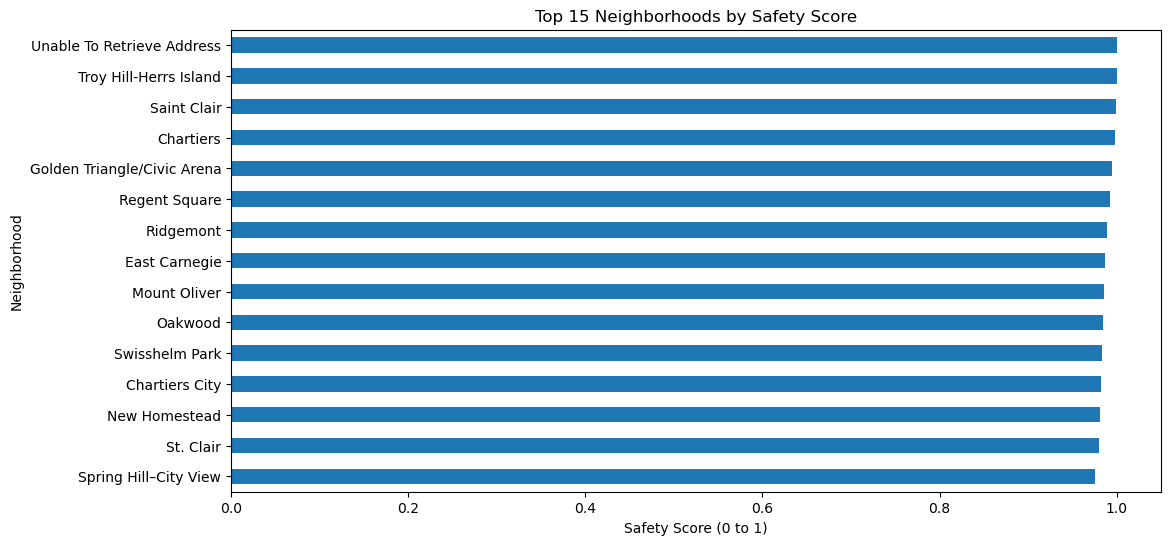

In [12]:

top15 = results["safety_score"].head(15).sort_values()

plt.figure()
top15.plot(kind="barh")
plt.xlabel("Safety Score (0 to 1)")
plt.ylabel("Neighborhood")
plt.title("Top 15 Neighborhoods by Safety Score")
plt.show()


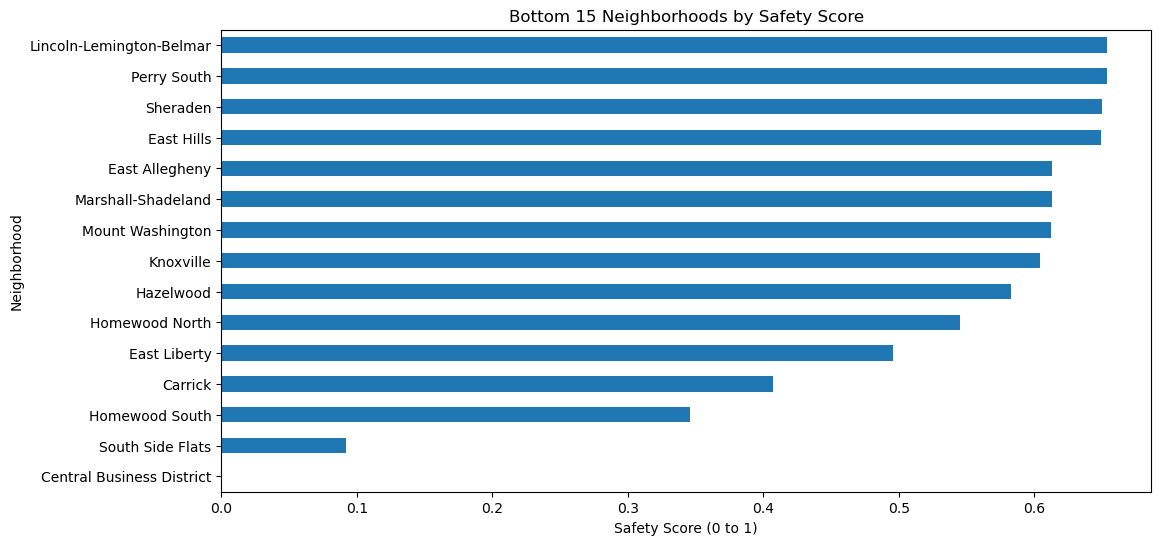

In [13]:

bottom15 = results["safety_score"].tail(15).sort_values()

plt.figure()
bottom15.plot(kind="barh")
plt.xlabel("Safety Score (0 to 1)")
plt.ylabel("Neighborhood")
plt.title("Bottom 15 Neighborhoods by Safety Score")
plt.show()



## Step 12: Why did the winning neighborhood rank first?

In [14]:

winner = results.index[0]

winner_profile = normalized.loc[winner]
city_avg_profile = normalized.mean()

explanation = pd.DataFrame({
    "winner_normalized_value": winner_profile,
    "citywide_average_normalized_value": city_avg_profile,
    "difference_from_city_avg": winner_profile - city_avg_profile,
}).sort_values("difference_from_city_avg")

explanation


,winner_normalized_value,citywide_average_normalized_value,difference_from_city_avg
fire,0.000000,0.279399,-0.279399
arrests,0.000000,0.146019,-0.146019
firearm,0.000000,0.142354,-0.142354
facilities,0.000000,0.139796,-0.139796
crime,0.000000,0.089754,-0.089754
citations,0.002027,0.045388,-0.043361


In [15]:

print(f"Neighborhood selected: {winner}")
print()

for metric_name in ["crime", "arrests", "firearm", "fire", "citations", "facilities"]:
    winner_val = winner_profile[metric_name]
    avg_val = city_avg_profile[metric_name]
    if metric_name == "facilities":
        relation = "above" if winner_val > avg_val else "below"
        print(f"- Facilities are {relation} the citywide average ({winner_val:.3f} vs {avg_val:.3f}).")
    else:
        relation = "below" if winner_val < avg_val else "above"
        print(f"- {metric_name.title()} is {relation} the citywide average ({winner_val:.3f} vs {avg_val:.3f}).")


Neighborhood selected: Unable To Retrieve Address

- Crime is below the citywide average (0.000 vs 0.090).
- Arrests is below the citywide average (0.000 vs 0.146).
- Firearm is below the citywide average (0.000 vs 0.142).
- Fire is below the citywide average (0.000 vs 0.279).
- Citations is below the citywide average (0.002 vs 0.045).
- Facilities are below the citywide average (0.000 vs 0.140).



## Interpretation

The algorithm chooses the neighborhood with the strongest overall balance of:

- lower normalized crime
- lower normalized arrests
- lower normalized firearm seizure totals
- lower normalized fire incident counts
- lower normalized non-traffic citation counts
- and at least some city facilities as a positive factor

Because the model is weighted, it does not treat all public safety events equally.  
For example, firearm-related activity and general crime matter more than citations.



## Limitations

I would say this notebook still has some important limitations:

1. **Counts are not population adjusted**  
   A neighborhood with more residents may naturally have more total incidents.

2. **Facilities are a rough proxy**  
   More facilities does not automatically mean a neighborhood is safer.

3. **A count based approach simplifies reality**  
   Severity, time trends, and exact incident context are not fully modeled.

4. **Weights are subjective**  
   The weights are defensible, but they reflect a judgment call rather than an objective truth.

5. **Dataset coverage differs**  
   Some datasets may cover different time ranges or reporting practices.



## Conclusion

The results show that neighborhoods like Highland Park, Lower Lawrenceville, Morningside, and Point Breeze come out as some of the safest areas in the city. These places tend to have lower risk scores and enough data behind them to make those results feel reliable, which suggests fewer serious incidents overall. On the other hand, neighborhoods such as South Side Flats, the Central Business District, East Liberty, and Allentown rank toward the bottom. In these areas, higher numbers of reported incidents and higher risk scores push them down in the rankings.

One of the biggest improvements in this model is the addition of a credibility metric, which basically accounts for how much data is available for each neighborhood. This helps avoid situations where a place looks “extremely safe” just because there isn’t much data recorded for it. Also, using risk scores instead of just raw counts makes the results more meaningful, since it considers how serious different types of incidents are instead of treating everything the same.

That said, there are still some limitations. The main issue is that the model relies on total incident counts rather than adjusting for population. Because of that, busier areas like downtown or entertainment districts can look less safe simply because more people are there and more incidents get reported. So, this model should be understood as showing relative levels of activity and risk, not as a perfect measure of how safe a neighborhood actually feels for residents.



## Appendix: Entire algorithm in one runnable code block

The next cell contains the entire pipeline in one place.  
If someone wants to run just the full algorithm from top to bottom, they can run that single block.


Top 15 neighborhoods by adjusted safety score


,safety_score,risk_score,signal,credibility
__neighborhood__,,,,
Highland Park,1.000000,0.375724,971.0,0.547505
Lower Lawrenceville,0.963969,0.396381,582.0,0.420368
Morningside,0.954073,0.402055,332.0,0.292640
Perry North,0.951724,0.403402,726.0,0.474975
Strip District,0.943707,0.407998,1050.0,0.566802
Polish Hill,0.943525,0.408102,345.0,0.300654
Banksville,0.934217,0.413439,521.0,0.393653
Lincoln Place,0.930804,0.415396,438.0,0.353083
Westwood,0.926335,0.417958,343.0,0.299433


Bottom 15 neighborhoods by adjusted safety score


,safety_score,risk_score,signal,credibility
__neighborhood__,,,,
Mount Washington,0.407963,0.715155,2400.0,0.749415
Larimer,0.397714,0.721032,1268.0,0.612412
Central Northside,0.397519,0.721143,1357.0,0.628386
Middle Hill,0.384650,0.728522,1369.0,0.630440
Marshall-Shadeland,0.338892,0.754756,1725.0,0.682493
Allentown,0.316175,0.767780,1948.0,0.708235
North Shore,0.280222,0.788393,1977.0,0.711279
Homewood South,0.265066,0.797083,2294.0,0.740836
Knoxville,0.247170,0.807343,2344.0,0.744955


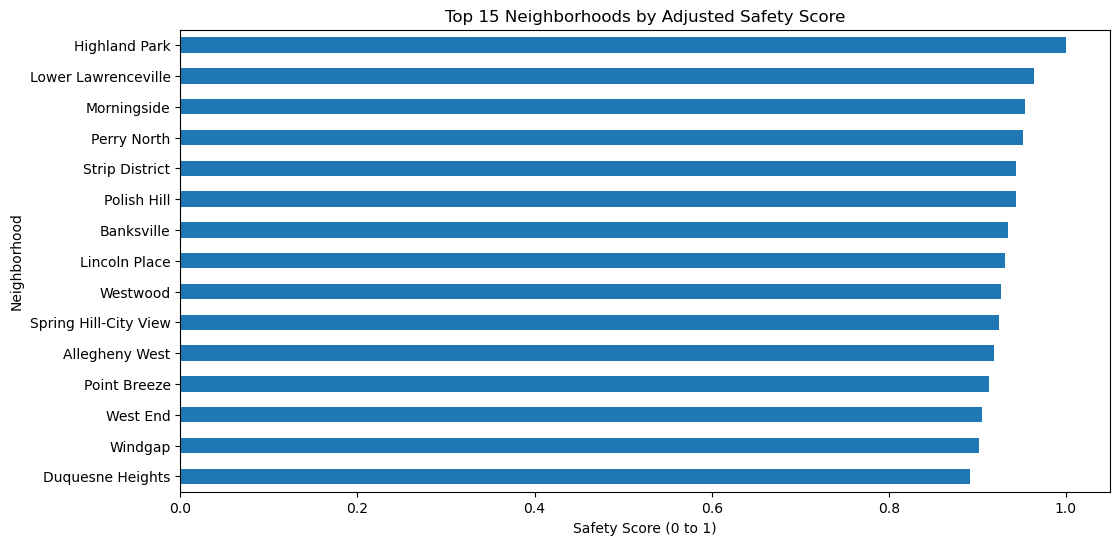

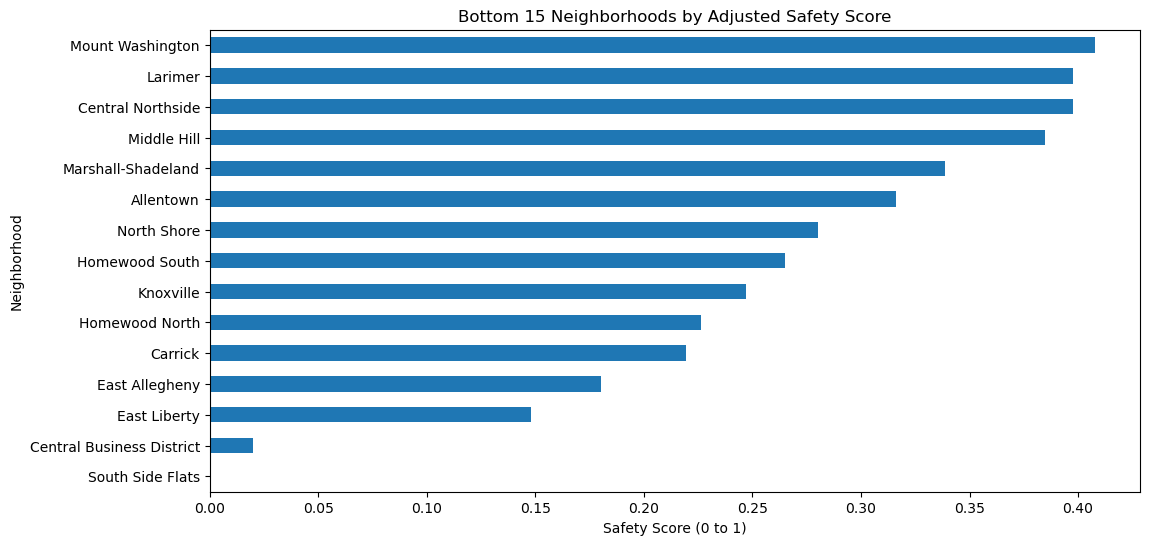

In [16]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12, 6)
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)

def resolve_data_dir():
    candidates = [Path("faaz_data"), Path("./faaz_data"), Path("/mnt/faaz_data"), Path(".")]
    for candidate in candidates:
        required = [
            candidate / "2024-2026 Monthly Criminal Activity Dataset.xlsx",
            candidate / "Arrests.csv",
            candidate / "Firearm Seizures Data.csv",
            candidate / "Fire Incidents.csv",
            candidate / "Non-Traffic Citations.csv",
            candidate / "City Facilities.csv",
        ]
        if candidate.exists() and all(path.exists() for path in required):
            return candidate
    raise FileNotFoundError("Could not find the required data files.")

DATA_DIR = resolve_data_dir()

crime = pd.read_excel(DATA_DIR / "2024-2026 Monthly Criminal Activity Dataset.xlsx")
arrests = pd.read_csv(DATA_DIR / "Arrests.csv")
firearm = pd.read_csv(DATA_DIR / "Firearm Seizures Data.csv")
fire = pd.read_csv(DATA_DIR / "Fire Incidents.csv")
citations = pd.read_csv(DATA_DIR / "Non-Traffic Citations.csv")
facilities = pd.read_csv(DATA_DIR / "City Facilities.csv")

def find_neighborhood_col(df):
    for col in df.columns:
        if "neighborhood" in col.lower():
            return col
    raise ValueError("No neighborhood-like column found.")

NEIGHBORHOOD_ALIASES = {
    "Central North Side": "Central Northside",
    "Golden Triangle/Civic Arena": "Central Business District",
    "St. Clair": "Saint Clair",
    "Mt. Oliver Boro": "Mount Oliver",
    "Mount Oliver Borough": "Mount Oliver",
    "Mt Oliver": "Mount Oliver",
    "Mt. Oliver": "Mount Oliver",
    "Mt. Oliver Neighborhood": "Mount Oliver",
    "Unable To Retrieve Address": np.nan,
    "Outside City": np.nan,
    "Outside County": np.nan,
    "Outside State": np.nan,
    "Unknown": np.nan,
    "NaN": np.nan,
    "": np.nan,
}

def prep_neighborhood_df(df):
    neighborhood_col = find_neighborhood_col(df)
    out = df.copy()
    out["__neighborhood__"] = out[neighborhood_col].apply(
        lambda v: np.nan if pd.isna(v) else str(v).strip()
    )
    out["__neighborhood__"] = out["__neighborhood__"].replace(NEIGHBORHOOD_ALIASES)
    out = out.dropna(subset=["__neighborhood__"]).copy()
    return out

crime_n = prep_neighborhood_df(crime)
arrests_n = prep_neighborhood_df(arrests)
firearm_n = prep_neighborhood_df(firearm)
fire_n = prep_neighborhood_df(fire)
citations_n = prep_neighborhood_df(citations)
facilities_n = prep_neighborhood_df(facilities)

# Crime severity weights
VIOLENT_WEIGHTS = {
    "Assault Offenses": 4.0,
    "Robbery": 4.5,
    "Homicide Offenses": 8.0,
    "Kidnapping/Abduction": 6.0,
    "Sex Offenses": 5.0,
    "Weapon Law Violations": 4.5,
}
PROPERTY_WEIGHTS = {
    "Burglary/Breaking & Entering": 3.2,
    "Motor Vehicle Theft": 3.0,
    "Larceny/Theft Offenses": 2.2,
    "Destruction/Damage/Vandalism of Property": 1.8,
    "Arson": 4.0,
    "Fraud Offenses": 1.4,
}
DEFAULT_CRIME_WEIGHT = 1.0

crime_n["severity_weight"] = crime_n["NIBRS_Offense_Category"].map(
    lambda x: VIOLENT_WEIGHTS.get(x, PROPERTY_WEIGHTS.get(x, DEFAULT_CRIME_WEIGHT))
)

metrics = pd.concat(
    [
        crime_n.groupby("__neighborhood__")["severity_weight"].sum().rename("crime_severity"),
        crime_n[crime_n["NIBRS_Offense_Category"].isin(VIOLENT_WEIGHTS)].groupby("__neighborhood__").size().rename("violent_crime"),
        crime_n[crime_n["NIBRS_Offense_Category"].isin(PROPERTY_WEIGHTS)].groupby("__neighborhood__").size().rename("property_crime"),
        crime_n[
            ~crime_n["NIBRS_Offense_Category"].isin(list(VIOLENT_WEIGHTS) + list(PROPERTY_WEIGHTS))
        ].groupby("__neighborhood__").size().rename("other_crime"),
        arrests_n.groupby("__neighborhood__").size().rename("arrests"),
        firearm_n.groupby("__neighborhood__")["total_count"].sum().rename("firearm"),
        fire_n.groupby("__neighborhood__").size().rename("fire"),
        citations_n.groupby("__neighborhood__").size().rename("citations"),
        facilities_n.groupby("__neighborhood__").size().rename("facilities"),
    ],
    axis=1,
).fillna(0)

# Do NOT reward facilities as "safer."
# Instead, use a mild exposure adjustment so neighborhoods with more activity
# are not automatically punished just because more things happen there.
exposure = np.sqrt(1 + metrics["facilities"])

rate_metrics = metrics.copy()
risk_cols = [
    "crime_severity",
    "violent_crime",
    "property_crime",
    "other_crime",
    "arrests",
    "firearm",
    "fire",
    "citations",
]
for col in risk_cols:
    rate_metrics[col] = np.log1p(metrics[col] / exposure)

# Percentile-rank normalization is more robust than min-max here.
normalized = rate_metrics.copy()
for col in risk_cols:
    normalized[col] = rate_metrics[col].rank(method="average", pct=True)

WEIGHTS = {
    "crime_severity": 0.30,
    "violent_crime": 0.25,
    "property_crime": 0.15,
    "firearm": 0.15,
    "fire": 0.07,
    "arrests": 0.05,
    "citations": 0.03,
}

raw_risk = sum(normalized[col] * weight for col, weight in WEIGHTS.items())

# Reliability shrinkage:
# neighborhoods with tiny sample sizes should be pulled toward the city average
# instead of topping the rankings from almost no data.
signal = metrics[["violent_crime", "property_crime", "other_crime", "firearm", "fire", "citations"]].sum(axis=1)
k = signal.median()
citywide_mean_risk = raw_risk.mean()
credibility = signal / (signal + k)

adjusted_risk = credibility * raw_risk + (1 - credibility) * citywide_mean_risk
safety_score = 1 - (adjusted_risk - adjusted_risk.min()) / (adjusted_risk.max() - adjusted_risk.min())

results = pd.concat(
    [
        pd.DataFrame(
            {
                "safety_score": safety_score,
                "risk_score": adjusted_risk,
                "signal": signal,
                "credibility": credibility,
            }
        ),
        metrics,
    ],
    axis=1,
).sort_values("safety_score", ascending=False)

print("Top 15 neighborhoods by adjusted safety score")
display(results[["safety_score", "risk_score", "signal", "credibility"]].head(15))

print("Bottom 15 neighborhoods by adjusted safety score")
display(results[["safety_score", "risk_score", "signal", "credibility"]].tail(15))

plt.figure()
results["safety_score"].head(15).sort_values().plot(kind="barh")
plt.xlabel("Safety Score (0 to 1)")
plt.ylabel("Neighborhood")
plt.title("Top 15 Neighborhoods by Adjusted Safety Score")
plt.show()

plt.figure()
results["safety_score"].tail(15).sort_values().plot(kind="barh")
plt.xlabel("Safety Score (0 to 1)")
plt.ylabel("Neighborhood")
plt.title("Bottom 15 Neighborhoods by Adjusted Safety Score")
plt.show()